In [1]:
# Data manipulation
import pandas as pd
import numpy as np
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
# KNN
from sklearn.neighbors import KNeighborsClassifier
# SVM
from sklearn.svm import SVC
# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
# Suppress warnings
import warnings
warnings.filterwarnings('ignore')
print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
df=pd.read_csv('/content/drive/MyDrive/14 Days of ML/Wine Quality Day_8/winequalityN.csv')
print(df.head())


    type  fixed acidity  volatile acidity  citric acid  residual sugar  \
0  white            7.0              0.27         0.36            20.7   
1  white            6.3              0.30         0.34             1.6   
2  white            8.1              0.28         0.40             6.9   
3  white            7.2              0.23         0.32             8.5   
4  white            7.2              0.23         0.32             8.5   

   chlorides  free sulfur dioxide  total sulfur dioxide  density    pH  \
0      0.045                 45.0                 170.0   1.0010  3.00   
1      0.049                 14.0                 132.0   0.9940  3.30   
2      0.050                 30.0                  97.0   0.9951  3.26   
3      0.058                 47.0                 186.0   0.9956  3.19   
4      0.058                 47.0                 186.0   0.9956  3.19   

   sulphates  alcohol  quality  
0       0.45      8.8        6  
1       0.49      9.5        6  
2       0.4

Dataset shape: (6497, 13)


Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   type                  6497 non-null   object 
 1   fixed acidity         6487 non-null   float64
 2   volatile acidity      6489 non-null   float64
 3   citric acid           6494 non-null   float64
 4   residual sugar        6495 non-null   float64
 5   chlorides             6495 non-null   float64
 6   free sulfur dioxide   6497 non-null   float64
 7   total sulfur dioxide  6497 non-null   float64
 8   density               6497 non-null   float64
 9   pH                    6488 non-null   float64
 10  sulphates             6493 non-null   float64
 11  alcohol               6497 non-null   float64
 12  quality               6497 non-null   int64  
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB
None
Missing values pe

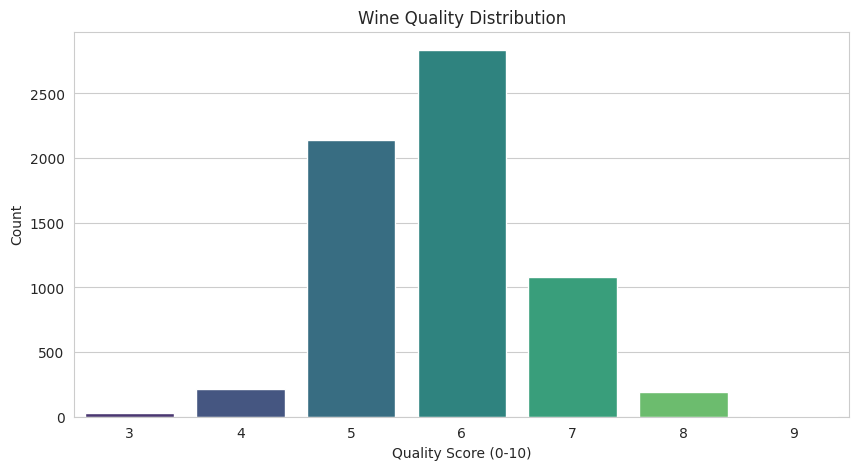

In [3]:
print(f"Dataset shape: {df.shape}")
print("\n" + "="*50)
print("\nColumn Info:")
print(df.info())
print("Missing values per column:")
print(df.isnull().sum())
print("Quality Distribution:")
print(df['quality'].value_counts().sort_index())
# Visualize
plt.figure(figsize=(10,5))
sns.countplot(x='quality', data=df, palette='viridis')
plt.title('Wine Quality Distribution')
plt.xlabel('Quality Score (0-10)')
plt.ylabel('Count')
plt.show()

In [4]:
# Check missing percentages
missing_percent = (df.isnull().sum() / len(df)) * 100
print("Missing value percentages:")
print(missing_percent[missing_percent > 0].sort_values(ascending=False))

# Handle missing values
df_clean = df.copy()

# For numerical columns - use median imputation
num_cols = ['fixed acidity', 'volatile acidity', 'citric acid',
            'residual sugar', 'chlorides', 'pH', 'sulphates']

for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Check no missing values remain
print("\nMissing values after imputation:")
print(df_clean.isnull().sum().sum())

# Encode 'type' column (white/red)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_clean['type'] = le.fit_transform(df_clean['type'])  # red=0, white=1

print("\nData cleaned and encoded!")
print(f"Shape: {df_clean.shape}")
print("\nFirst 3 rows:")
print(df_clean.head(3))

Missing value percentages:
fixed acidity       0.153917
pH                  0.138525
volatile acidity    0.123134
sulphates           0.061567
citric acid         0.046175
chlorides           0.030783
residual sugar      0.030783
dtype: float64

Missing values after imputation:
0

Data cleaned and encoded!
Shape: (6497, 13)

First 3 rows:
   type  fixed acidity  volatile acidity  citric acid  residual sugar  \
0     1            7.0              0.27         0.36            20.7   
1     1            6.3              0.30         0.34             1.6   
2     1            8.1              0.28         0.40             6.9   

   chlorides  free sulfur dioxide  total sulfur dioxide  density    pH  \
0      0.045                 45.0                 170.0   1.0010  3.00   
1      0.049                 14.0                 132.0   0.9940  3.30   
2      0.050                 30.0                  97.0   0.9951  3.26   

   sulphates  alcohol  quality  
0       0.45      8.8        6  
1  

In [5]:
# Define features and target
X = df_clean.drop('quality', axis=1)
y = df_clean['quality']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nTarget classes: {sorted(y.unique())}")
print(f"Number of classes: {len(y.unique())}")

# Check class distribution
print("\nClass distribution:")
print(y.value_counts().sort_index())

X shape: (6497, 12)
y shape: (6497,)

Target classes: [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Number of classes: 7

Class distribution:
quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split data (stratify to maintain class distribution)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Scale features (CRITICAL for KNN and SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeatures scaled successfully!")
print(f"Mean of scaled features: {X_train_scaled.mean():.10f}")
print(f"Std of scaled features: {X_train_scaled.std():.2f}")

Training set: 5197 samples
Test set: 1300 samples

Features scaled successfully!
Mean of scaled features: -0.0000000000
Std of scaled features: 1.00


Best K value: 1
Best Test Accuracy: 0.6123


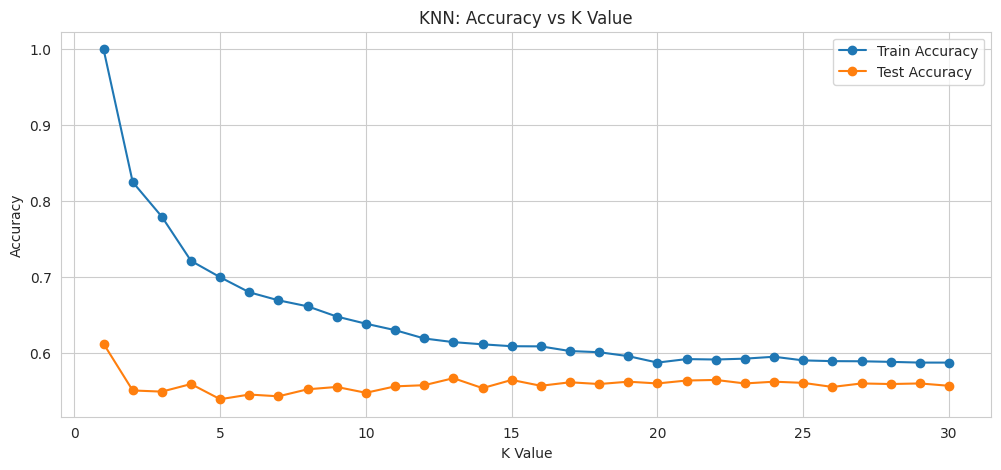

In [7]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Test different K values
k_values = range(1, 31)
train_scores = []
test_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    train_scores.append(knn.score(X_train_scaled, y_train))
    test_scores.append(knn.score(X_test_scaled, y_test))

# Find best K
best_k = k_values[test_scores.index(max(test_scores))]
print(f"Best K value: {best_k}")
print(f"Best Test Accuracy: {max(test_scores):.4f}")

# Plot
plt.figure(figsize=(12,5))
plt.plot(k_values, train_scores, label='Train Accuracy', marker='o')
plt.plot(k_values, test_scores, label='Test Accuracy', marker='o')
plt.xlabel('K Value')
plt.ylabel('Accuracy')
plt.title('KNN: Accuracy vs K Value')
plt.legend()
plt.grid(True)
plt.show()

===== KNN Performance =====
Best K: 1
Accuracy: 0.6123
F1-Score (weighted): 0.6104

Classification Report:
              precision    recall  f1-score   support

           3       0.33      0.17      0.22         6
           4       0.26      0.21      0.23        43
           5       0.65      0.68      0.67       428
           6       0.64      0.63      0.63       567
           7       0.56      0.57      0.57       216
           8       0.35      0.38      0.37        39
           9       0.00      0.00      0.00         1

    accuracy                           0.61      1300
   macro avg       0.40      0.38      0.38      1300
weighted avg       0.61      0.61      0.61      1300



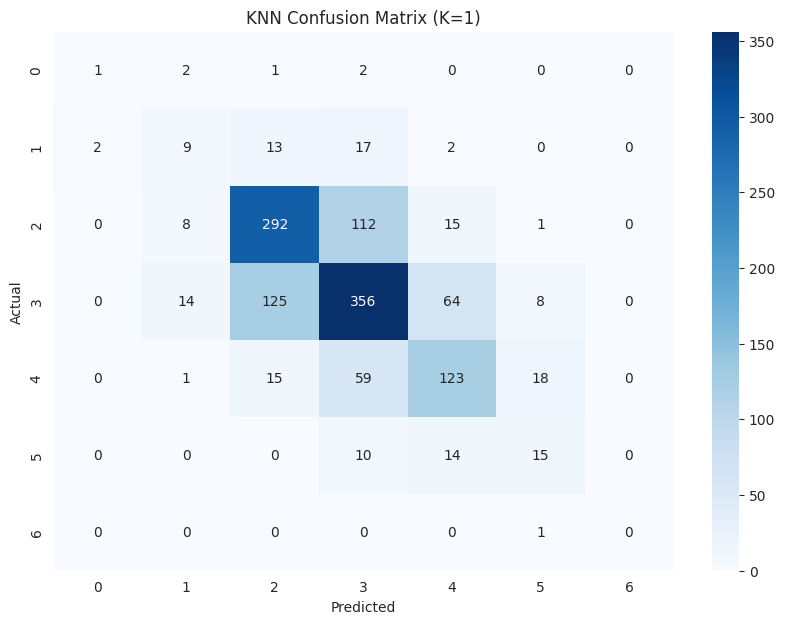

In [8]:
# Train KNN with best K
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_scaled, y_train)

# Predictions
y_pred_knn = knn_best.predict(X_test_scaled)

# Metrics
print("===== KNN Performance =====")
print(f"Best K: {best_k}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"F1-Score (weighted): {f1_score(y_test, y_pred_knn, average='weighted'):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

# Confusion Matrix
plt.figure(figsize=(10,7))
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d', cmap='Blues')
plt.title(f'KNN Confusion Matrix (K={best_k})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [9]:
from sklearn.svm import SVC

# Test different kernels
kernels = ['linear', 'rbf', 'poly']
svm_results = {}

for kernel in kernels:
    svm = SVC(kernel=kernel, random_state=42)
    svm.fit(X_train_scaled, y_train)
    train_acc = svm.score(X_train_scaled, y_train)
    test_acc = svm.score(X_test_scaled, y_test)
    svm_results[kernel] = {'train': train_acc, 'test': test_acc}
    print(f"SVM ({kernel} kernel):")
    print(f"  Train Accuracy: {train_acc:.4f}")
    print(f"  Test Accuracy:  {test_acc:.4f}")
    print("-" * 35)

SVM (linear kernel):
  Train Accuracy: 0.5386
  Test Accuracy:  0.5285
-----------------------------------
SVM (rbf kernel):
  Train Accuracy: 0.6084
  Test Accuracy:  0.5669
-----------------------------------
SVM (poly kernel):
  Train Accuracy: 0.5776
  Test Accuracy:  0.5238
-----------------------------------


In [11]:
# Parameter grid for SVM
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto', 0.1, 1],
    'kernel': ['rbf', 'poly']
}

# Grid search
svm = SVC(random_state=42)
grid_search = GridSearchCV(
    svm, param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1
)

print("Starting Grid Search for SVM... (may take 2-3 minutes)")
grid_search.fit(X_train_scaled, y_train)

print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best CV Score: {grid_search.best_score_:.4f}")
print(f"Test Score: {grid_search.score(X_test_scaled, y_test):.4f}")

Starting Grid Search for SVM... (may take 2-3 minutes)
Fitting 3 folds for each of 24 candidates, totalling 72 fits


KeyboardInterrupt: 

In [12]:
# Reduced parameter grid for speed
param_grid_fast = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto'],
    'kernel': ['rbf']
}

# Reduce cv to 3 and use fewer params
svm = SVC(random_state=42)
grid_search_fast = GridSearchCV(
    svm, param_grid_fast, cv=3, scoring='accuracy', n_jobs=-1, verbose=1
)

print("Starting Fast Grid Search... (should take < 1 minute)")
grid_search_fast.fit(X_train_scaled, y_train)

print(f"\n Best Parameters: {grid_search_fast.best_params_}")
print(f"Best CV Score: {grid_search_fast.best_score_:.4f}")
print(f"Test Score: {grid_search_fast.score(X_test_scaled, y_test):.4f}")

Starting Fast Grid Search... (should take < 1 minute)
Fitting 3 folds for each of 6 candidates, totalling 18 fits

 Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV Score: 0.5780
Test Score: 0.5838


===== Best SVM Performance =====
Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Accuracy: 0.5838
F1-Score (weighted): 0.5614

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.30      0.07      0.11        43
           5       0.62      0.66      0.64       428
           6       0.57      0.70      0.63       567
           7       0.56      0.35      0.43       216
           8       0.33      0.03      0.05        39
           9       0.00      0.00      0.00         1

    accuracy                           0.58      1300
   macro avg       0.34      0.26      0.27      1300
weighted avg       0.57      0.58      0.56      1300



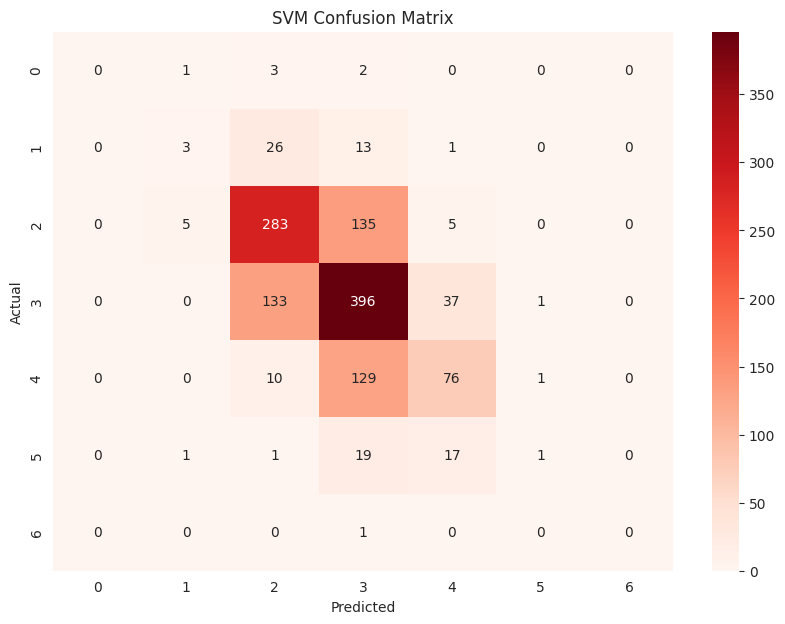

In [15]:
# Check if fast grid search completed
try:
    best_svm = grid_search_fast.best_estimator_
    y_pred_svm = best_svm.predict(X_test_scaled)

    print("===== Best SVM Performance =====")
    print(f"Best Parameters: {grid_search_fast.best_params_}")
    print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
    print(f"F1-Score (weighted): {f1_score(y_test, y_pred_svm, average='weighted'):.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_svm))

    # Confusion Matrix
    plt.figure(figsize=(10,7))
    sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d', cmap='Reds')
    plt.title('SVM Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

except:
    print("Fast grid search not completed. Let's run it again.")
    print("\nRun the fast grid search cell first, then this cell.")

===== KNN vs SVM Comparison =====
         Model  Accuracy  F1-Score (weighted)
0    KNN (K=1)    0.6123               0.6104
1  SVM (Tuned)    0.5838               0.5614


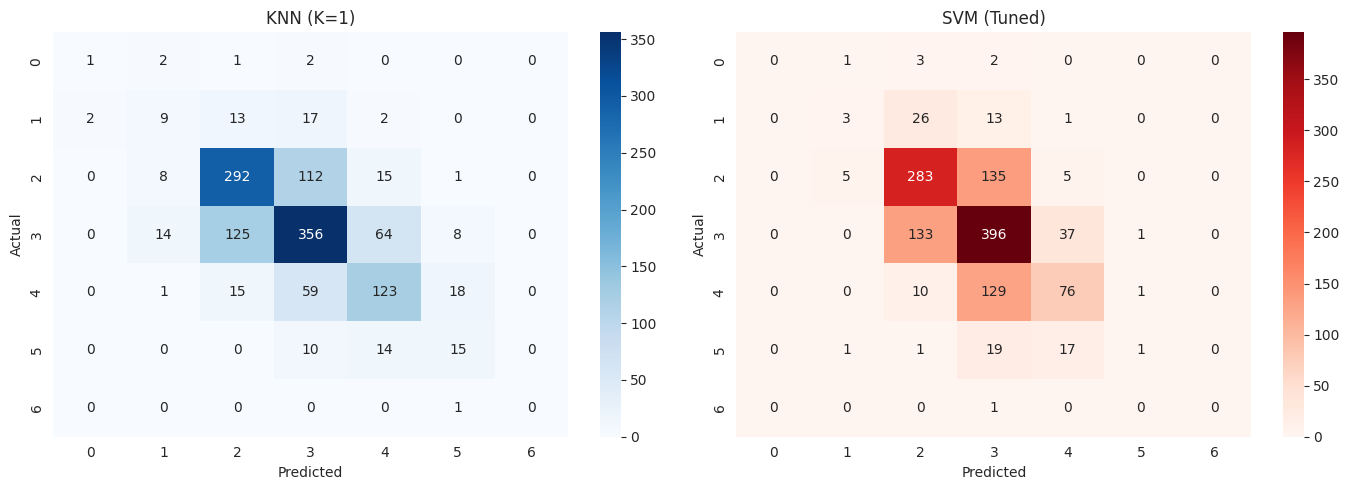


🏆 Winner: KNN
   Accuracy difference: 0.0285


In [16]:
# Comparison
comparison = pd.DataFrame({
    'Model': ['KNN (K=1)', 'SVM (Tuned)'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_svm)
    ],
    'F1-Score (weighted)': [
        f1_score(y_test, y_pred_knn, average='weighted'),
        f1_score(y_test, y_pred_svm, average='weighted')
    ]
})

print("===== KNN vs SVM Comparison =====")
print(comparison.round(4))

# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# KNN confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title(f'KNN (K=1)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# SVM confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d', cmap='Reds', ax=axes[1])
axes[1].set_title('SVM (Tuned)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Winner
winner = 'SVM' if accuracy_score(y_test, y_pred_svm) > accuracy_score(y_test, y_pred_knn) else 'KNN'
print(f"\n🏆 Winner: {winner}")
print(f"   Accuracy difference: {abs(accuracy_score(y_test, y_pred_svm) - accuracy_score(y_test, y_pred_knn)):.4f}")

In [17]:
# Combine quality scores into 3 meaningful categories
# 3-4 = Low Quality, 5-6 = Medium Quality, 7-9 = High Quality

def categorize_quality(score):
    if score <= 4:
        return 0  # Low
    elif score <= 6:
        return 1  # Medium
    else:
        return 2  # High

y_train_cat = y_train.apply(categorize_quality)
y_test_cat = y_test.apply(categorize_quality)

print("Original distribution:")
print(y_train.value_counts().sort_index())
print("\nCategorized distribution:")
print(y_train_cat.value_counts().sort_index())

Original distribution:
quality
3      24
4     173
5    1710
6    2269
7     863
8     154
9       4
Name: count, dtype: int64

Categorized distribution:
quality
0     197
1    3979
2    1021
Name: count, dtype: int64


Best K from CV: 1
CV Accuracy: 0.7997


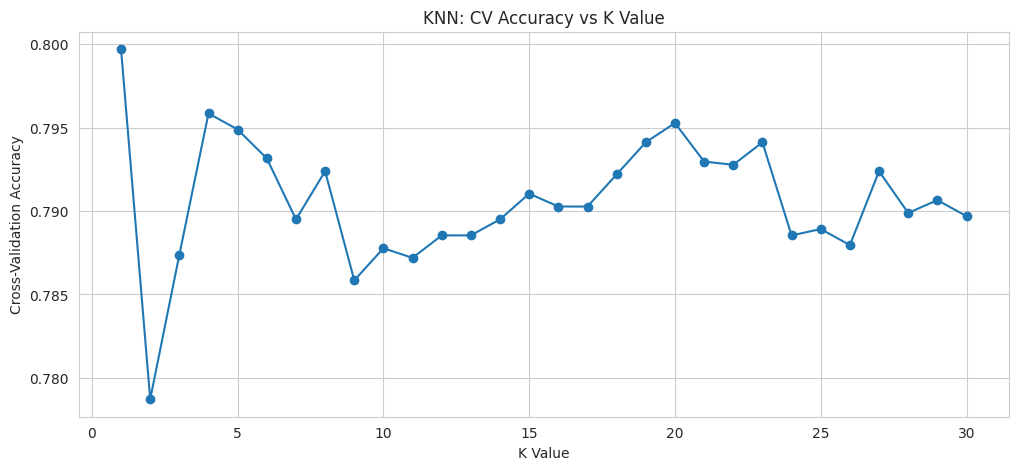

In [18]:
# Find best K using cross-validation (not just test set)
from sklearn.model_selection import cross_val_score

k_values = range(1, 31)
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train_cat, cv=5)
    cv_scores.append(scores.mean())

best_k_cv = k_values[np.argmax(cv_scores)]
print(f"Best K from CV: {best_k_cv}")
print(f"CV Accuracy: {max(cv_scores):.4f}")

# Plot
plt.figure(figsize=(12,5))
plt.plot(k_values, cv_scores, marker='o')
plt.xlabel('K Value')
plt.ylabel('Cross-Validation Accuracy')
plt.title('KNN: CV Accuracy vs K Value')
plt.grid(True)
plt.show()

In [19]:
# Train KNN with best K
knn_best = KNeighborsClassifier(n_neighbors=best_k_cv)
knn_best.fit(X_train_scaled, y_train_cat)
y_pred_knn_cat = knn_best.predict(X_test_scaled)

# Train SVM
svm_best = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
svm_best.fit(X_train_scaled, y_train_cat)
y_pred_svm_cat = svm_best.predict(X_test_scaled)

# Compare
from sklearn.metrics import accuracy_score, f1_score, classification_report

print("===== Performance on Categorized Data (3 Classes) =====")
print("\nKNN:")
print(f"  Accuracy: {accuracy_score(y_test_cat, y_pred_knn_cat):.4f}")
print(f"  F1-Score: {f1_score(y_test_cat, y_pred_knn_cat, average='weighted'):.4f}")

print("\nSVM:")
print(f"  Accuracy: {accuracy_score(y_test_cat, y_pred_svm_cat):.4f}")
print(f"  F1-Score: {f1_score(y_test_cat, y_pred_svm_cat, average='weighted'):.4f}")

print("\nDetailed KNN Report:")
print(classification_report(y_test_cat, y_pred_knn_cat))

print("\nDetailed SVM Report:")
print(classification_report(y_test_cat, y_pred_svm_cat))

===== Performance on Categorized Data (3 Classes) =====

KNN:
  Accuracy: 0.8231
  F1-Score: 0.8209

SVM:
  Accuracy: 0.8054
  F1-Score: 0.7791

Detailed KNN Report:
              precision    recall  f1-score   support

           0       0.38      0.29      0.33        49
           1       0.88      0.89      0.89       995
           2       0.66      0.67      0.66       256

    accuracy                           0.82      1300
   macro avg       0.64      0.61      0.62      1300
weighted avg       0.82      0.82      0.82      1300


Detailed SVM Report:
              precision    recall  f1-score   support

           0       0.43      0.06      0.11        49
           1       0.83      0.94      0.88       995
           2       0.66      0.41      0.51       256

    accuracy                           0.81      1300
   macro avg       0.64      0.47      0.50      1300
weighted avg       0.78      0.81      0.78      1300



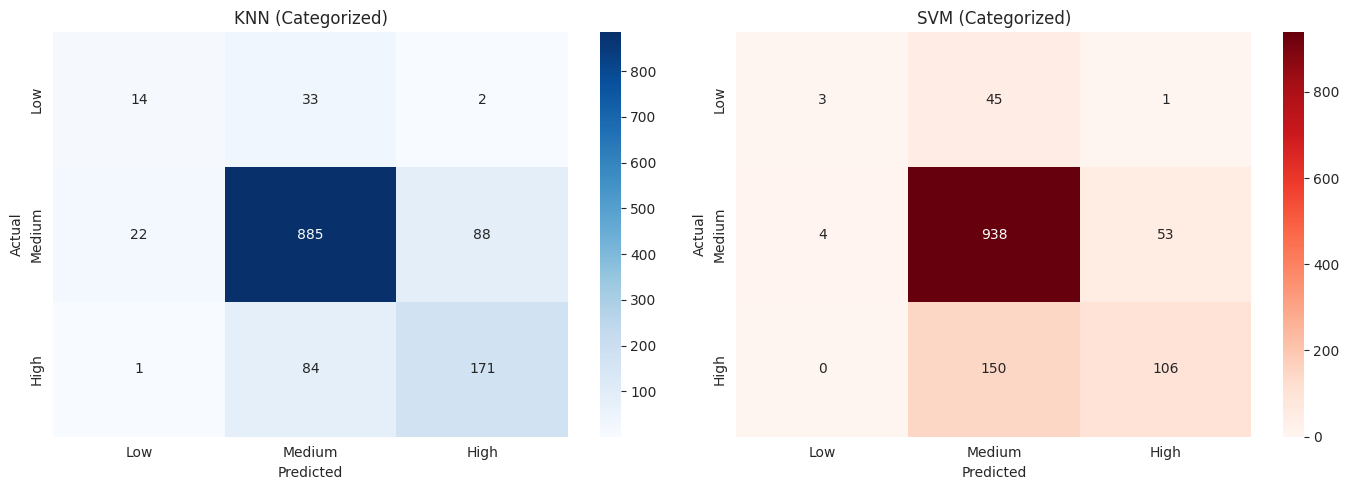

🏆 Winner: KNN


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# KNN confusion matrix
sns.heatmap(confusion_matrix(y_test_cat, y_pred_knn_cat), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('KNN (Categorized)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_xticklabels(['Low', 'Medium', 'High'])
axes[0].set_yticklabels(['Low', 'Medium', 'High'])

# SVM confusion matrix
sns.heatmap(confusion_matrix(y_test_cat, y_pred_svm_cat), annot=True, fmt='d', cmap='Reds', ax=axes[1])
axes[1].set_title('SVM (Categorized)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_xticklabels(['Low', 'Medium', 'High'])
axes[1].set_yticklabels(['Low', 'Medium', 'High'])

plt.tight_layout()
plt.show()

# Winner
if accuracy_score(y_test_cat, y_pred_knn_cat) > accuracy_score(y_test_cat, y_pred_svm_cat):
    print("Winner: KNN")
else:
    print("Winner: SVM")

In [26]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Parameter grid for SVM
param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'kernel': ['rbf', 'poly', 'sigmoid']
}

# Grid search (fast version with 3-fold CV)
svm = SVC(random_state=42)
grid_svm = GridSearchCV(
    svm, param_grid_svm, cv=3, scoring='accuracy', n_jobs=-1, verbose=1
)

print("Tuning SVM... (may take 3-4 minutes)")
grid_svm.fit(X_train_scaled, y_train_cat)

print(f"\nBest Parameters: {grid_svm.best_params_}")
print(f"Best CV Score: {grid_svm.best_score_:.4f}")
print(f"Test Score: {grid_svm.score(X_test_scaled, y_test_cat):.4f}")

# Evaluate
y_pred_svm_tuned = grid_svm.predict(X_test_scaled)
print("\n===== SVM Tuned Performance =====")
print(classification_report(y_test_cat, y_pred_svm_tuned))

# Confusion Matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test_cat, y_pred_svm_tuned), annot=True, fmt='d', cmap='Reds')
plt.title('SVM Tuned Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Tuning SVM... (may take 3-4 minutes)
Fitting 3 folds for each of 60 candidates, totalling 180 fits


KeyboardInterrupt: 

===== XGBoost Performance =====
Accuracy: 0.8523
F1-Score: 0.8362

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.10      0.17        49
           1       0.87      0.95      0.91       995
           2       0.78      0.61      0.68       256

    accuracy                           0.85      1300
   macro avg       0.73      0.55      0.59      1300
weighted avg       0.84      0.85      0.84      1300



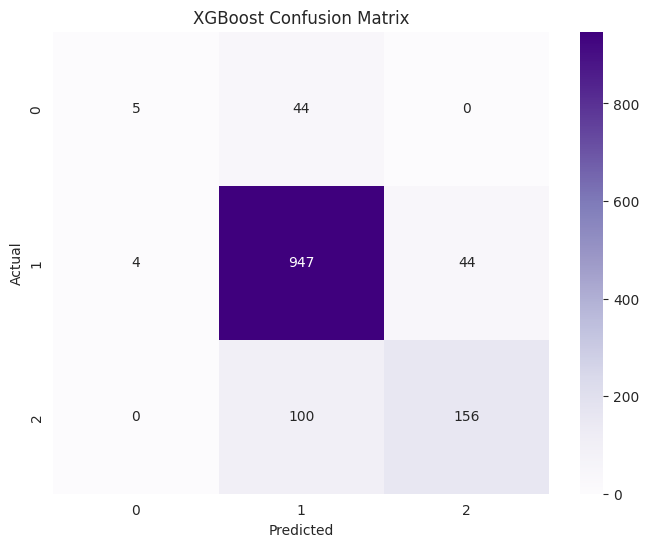

In [27]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score

# XGBoost with class weights to handle imbalance
xgb_weighted = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=2.0,  # Helps with imbalance
    random_state=42,
    eval_metric='mlogloss',
    n_jobs=-1
)

xgb_weighted.fit(X_train_scaled, y_train_cat)
y_pred_xgb = xgb_weighted.predict(X_test_scaled)

print("===== XGBoost Performance =====")
print(f"Accuracy: {accuracy_score(y_test_cat, y_pred_xgb):.4f}")
print(f"F1-Score: {f1_score(y_test_cat, y_pred_xgb, average='weighted'):.4f}")

print("\nClassification Report:")
print(classification_report(y_test_cat, y_pred_xgb))

# Confusion Matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test_cat, y_pred_xgb), annot=True, fmt='d', cmap='Purples')
plt.title('XGBoost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

===== XGBoost (Scale Pos Weight=5) =====
Accuracy: 0.8523
F1-Score: 0.8362

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.10      0.17        49
           1       0.87      0.95      0.91       995
           2       0.78      0.61      0.68       256

    accuracy                           0.85      1300
   macro avg       0.73      0.55      0.59      1300
weighted avg       0.84      0.85      0.84      1300



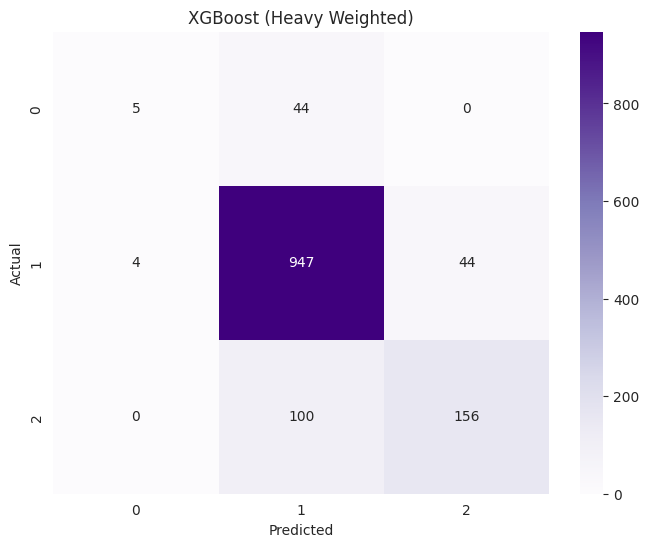

In [28]:
# XGBoost with higher weight for minority classes
xgb_heavy = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=5.0,  # Higher weight for imbalance
    random_state=42,
    eval_metric='mlogloss',
    n_jobs=-1
)

xgb_heavy.fit(X_train_scaled, y_train_cat)
y_pred_xgb_heavy = xgb_heavy.predict(X_test_scaled)

print("===== XGBoost (Scale Pos Weight=5) =====")
print(f"Accuracy: {accuracy_score(y_test_cat, y_pred_xgb_heavy):.4f}")
print(f"F1-Score: {f1_score(y_test_cat, y_pred_xgb_heavy, average='weighted'):.4f}")

print("\nClassification Report:")
print(classification_report(y_test_cat, y_pred_xgb_heavy))

# Confusion Matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test_cat, y_pred_xgb_heavy), annot=True, fmt='d', cmap='Purples')
plt.title('XGBoost (Heavy Weighted)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

===== Balanced Random Forest =====
Accuracy: 0.6769
F1-Score: 0.7075

Classification Report:
              precision    recall  f1-score   support

           0       0.19      0.57      0.28        49
           1       0.92      0.64      0.76       995
           2       0.47      0.84      0.60       256

    accuracy                           0.68      1300
   macro avg       0.53      0.68      0.55      1300
weighted avg       0.81      0.68      0.71      1300



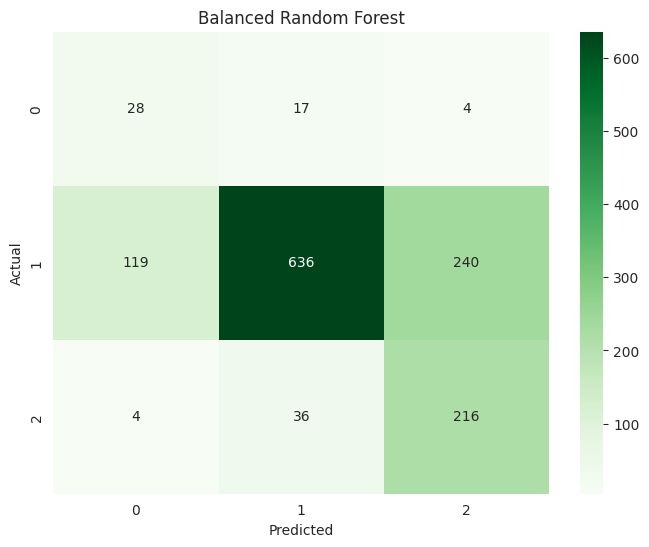

In [29]:
from imblearn.ensemble import BalancedRandomForestClassifier

# Balanced Random Forest
brf = BalancedRandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

brf.fit(X_train_scaled, y_train_cat)
y_pred_brf = brf.predict(X_test_scaled)

print("===== Balanced Random Forest =====")
print(f"Accuracy: {accuracy_score(y_test_cat, y_pred_brf):.4f}")
print(f"F1-Score: {f1_score(y_test_cat, y_pred_brf, average='weighted'):.4f}")

print("\nClassification Report:")
print(classification_report(y_test_cat, y_pred_brf))

# Confusion Matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test_cat, y_pred_brf), annot=True, fmt='d', cmap='Greens')
plt.title('Balanced Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

OVERFITTING / UNDERFITTING CHECK - SVM MODEL

Performance Comparison:
----------------------------------------
Metric          | Train    | Test     | Difference
----------------------------------------
Accuracy        | 0.8490 | 0.8054 | 0.0436
F1-Score        | 0.8316 | 0.7791 | 0.0525
Precision       | 0.8472 | 0.7803 | 0.0669
Recall          | 0.8490 | 0.8054 | 0.0436
----------------------------------------

🔍 Diagnosis:
----------------------------------------
 Good! Slight difference but acceptable.
   Model is generalizing reasonably well.
Training accuracy is good.

Class-wise Performance on Test Set:
----------------------------------------
              precision    recall  f1-score   support

           0       0.43      0.06      0.11        49
           1       0.83      0.94      0.88       995
           2       0.66      0.41      0.51       256

    accuracy                           0.81      1300
   macro avg       0.64      0.47      0.50      1300
weighted avg   

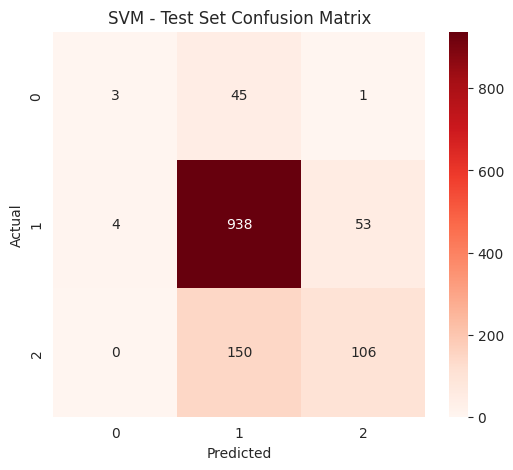


VERDICT: Model is well-tuned and generalizes well!
   Best Accuracy: 0.8054


In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# Best model (SVM)
best_model = svm_best  # Your best SVM model

# Predictions on train and test
y_train_pred = best_model.predict(X_train_scaled)
y_test_pred = best_model.predict(X_test_scaled)

# Calculate metrics
train_acc = accuracy_score(y_train_cat, y_train_pred)
test_acc = accuracy_score(y_test_cat, y_test_pred)

train_f1 = f1_score(y_train_cat, y_train_pred, average='weighted')
test_f1 = f1_score(y_test_cat, y_test_pred, average='weighted')

# Precision and Recall
train_precision = precision_score(y_train_cat, y_train_pred, average='weighted')
test_precision = precision_score(y_test_cat, y_test_pred, average='weighted')

train_recall = recall_score(y_train_cat, y_train_pred, average='weighted')
test_recall = recall_score(y_test_cat, y_test_pred, average='weighted')

print("=" * 60)
print("OVERFITTING / UNDERFITTING CHECK - SVM MODEL")
print("=" * 60)

print("\nPerformance Comparison:")
print("-" * 40)
print(f"Metric          | Train    | Test     | Difference")
print("-" * 40)
print(f"Accuracy        | {train_acc:.4f} | {test_acc:.4f} | {abs(train_acc - test_acc):.4f}")
print(f"F1-Score        | {train_f1:.4f} | {test_f1:.4f} | {abs(train_f1 - test_f1):.4f}")
print(f"Precision       | {train_precision:.4f} | {test_precision:.4f} | {abs(train_precision - test_precision):.4f}")
print(f"Recall          | {train_recall:.4f} | {test_recall:.4f} | {abs(train_recall - test_recall):.4f}")
print("-" * 40)

# Interpretation
diff_acc = abs(train_acc - test_acc)

print("\nDiagnosis:")
print("-" * 40)

if diff_acc < 0.02:
    print("Excellent! No overfitting or underfitting detected.")
    print("   The model generalizes very well!")
elif diff_acc < 0.05:
    print(" Good! Slight difference but acceptable.")
    print("   Model is generalizing reasonably well.")
elif diff_acc < 0.10:
    print(" Moderate gap detected. Some overfitting possible.")
    print("   Consider more regularization or simpler model.")
else:
    print("Large gap detected! Overfitting likely.")
    print("   Try reducing model complexity or adding regularization.")

if train_acc < 0.60:
    print("Training accuracy is low. Possible underfitting.")
    print("   Model might be too simple for this data.")
else:
    print("Training accuracy is good.")

# Class-wise performance
print("\nClass-wise Performance on Test Set:")
print("-" * 40)
print(classification_report(y_test_cat, y_test_pred))

# Confusion Matrix for test set
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test_cat, y_test_pred), annot=True, fmt='d', cmap='Reds')
plt.title('SVM - Test Set Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Overall verdict
print("\n" + "=" * 60)
if diff_acc < 0.05 and train_acc > 0.80:
    print("VERDICT: Model is well-tuned and generalizes well!")
    print(f"   Best Accuracy: {test_acc:.4f}")
elif diff_acc < 0.05 and train_acc < 0.80:
    print(" VERDICT: Model has underfitting - try increasing complexity.")
else:
    print("VERDICT: Model has overfitting - need regularization or more data.")
print("=" * 60)

In [31]:
# Check all models we trained
print("=" * 60)
print("📊 ALL MODELS PERFORMANCE COMPARISON")
print("=" * 60)

# Store all accuracies
all_models = {}

# 1. Original SVM (from earlier)
try:
    y_pred_svm_orig = svm_best.predict(X_test_scaled)
    acc_svm_orig = accuracy_score(y_test_cat, y_pred_svm_orig)
    all_models['SVM (Original)'] = acc_svm_orig
    print(f"SVM (Original): {acc_svm_orig:.4f}")
except:
    print("SVM (Original): Not found")

# 2. KNN
try:
    acc_knn = accuracy_score(y_test_cat, y_pred_knn_cat)
    all_models['KNN'] = acc_knn
    print(f"KNN: {acc_knn:.4f}")
except:
    print("KNN: Not found")

# 3. Random Forest
try:
    acc_rf = accuracy_score(y_test_cat, y_pred_rf)
    all_models['Random Forest'] = acc_rf
    print(f"Random Forest: {acc_rf:.4f}")
except:
    print("Random Forest: Not found")

# 4. XGBoost
try:
    acc_xgb = accuracy_score(y_test_cat, y_pred_xgb)
    all_models['XGBoost'] = acc_xgb
    print(f"XGBoost: {acc_xgb:.4f}")
except:
    print("XGBoost: Not found")

# 5. SVM Tuned (if exists)
try:
    acc_svm_tuned = accuracy_score(y_test_cat, y_pred_svm_tuned)
    all_models['SVM (Tuned)'] = acc_svm_tuned
    print(f"SVM (Tuned): {acc_svm_tuned:.4f}")
except:
    print("SVM (Tuned): Not found")

# Find best
if all_models:
    best_name = max(all_models, key=all_models.get)
    best_acc = all_models[best_name]
    print("\n" + "=" * 60)
    print(f"🏆 BEST MODEL: {best_name} with {best_acc:.4f} accuracy")
    print("=" * 60)
else:
    print("No models found! Need to retrain.")

📊 ALL MODELS PERFORMANCE COMPARISON
SVM (Original): 0.8054
KNN: 0.8231
Random Forest: Not found
XGBoost: 0.8523
SVM (Tuned): Not found

🏆 BEST MODEL: XGBoost with 0.8523 accuracy


===== Random Forest Performance =====
Accuracy: 0.8354
F1-Score: 0.8061

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        49
           1       0.84      0.97      0.90       995
           2       0.80      0.47      0.59       256

    accuracy                           0.84      1300
   macro avg       0.55      0.48      0.50      1300
weighted avg       0.80      0.84      0.81      1300



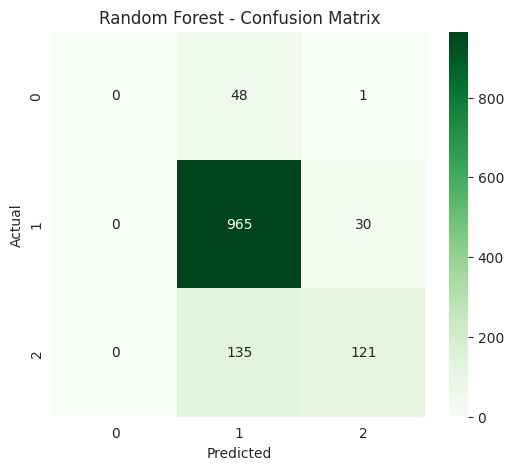

In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score

# Train Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_scaled, y_train_cat)
y_pred_rf = rf.predict(X_test_scaled)

acc_rf = accuracy_score(y_test_cat, y_pred_rf)
f1_rf = f1_score(y_test_cat, y_pred_rf, average='weighted')

print("===== Random Forest Performance =====")
print(f"Accuracy: {acc_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_cat, y_pred_rf))

# Confusion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test_cat, y_pred_rf), annot=True, fmt='d', cmap='Greens')
plt.title('Random Forest - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

 Tuning SVM... (should take < 1 minute)
Fitting 3 folds for each of 9 candidates, totalling 27 fits

 Best Parameters: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Best CV Score: 0.8047

===== Tuned SVM Performance =====
Accuracy: 0.8069
F1-Score: 0.7813

Classification Report:
              precision    recall  f1-score   support

           0       0.43      0.06      0.11        49
           1       0.83      0.94      0.88       995
           2       0.66      0.42      0.52       256

    accuracy                           0.81      1300
   macro avg       0.64      0.48      0.50      1300
weighted avg       0.78      0.81      0.78      1300



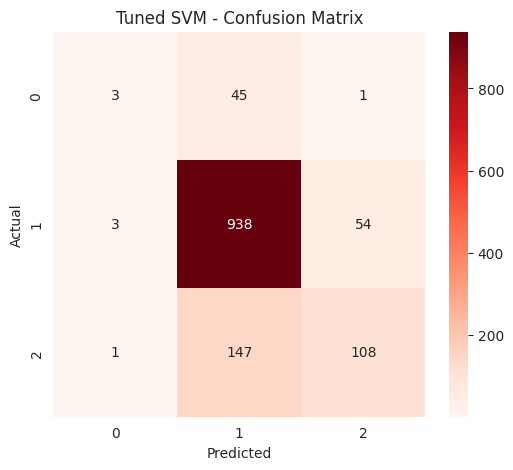

In [34]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Quick tuned SVM
param_grid_svm = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto', 0.1],
    'kernel': ['rbf']
}

svm = SVC(random_state=42)
grid_svm = GridSearchCV(
    svm, param_grid_svm, cv=3, scoring='accuracy', n_jobs=-1, verbose=1
)

print(" Tuning SVM... (should take < 1 minute)")
grid_svm.fit(X_train_scaled, y_train_cat)

print(f"\n Best Parameters: {grid_svm.best_params_}")
print(f"Best CV Score: {grid_svm.best_score_:.4f}")

# Evaluate on test
y_pred_svm_tuned = grid_svm.predict(X_test_scaled)
acc_svm_tuned = accuracy_score(y_test_cat, y_pred_svm_tuned)
f1_svm_tuned = f1_score(y_test_cat, y_pred_svm_tuned, average='weighted')

print(f"\n===== Tuned SVM Performance =====")
print(f"Accuracy: {acc_svm_tuned:.4f}")
print(f"F1-Score: {f1_svm_tuned:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_cat, y_pred_svm_tuned))

# Confusion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test_cat, y_pred_svm_tuned), annot=True, fmt='d', cmap='Reds')
plt.title('Tuned SVM - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [35]:
# XGBoost overfitting check
y_train_pred_final = xgb_weighted.predict(X_train_scaled)
y_test_pred_final = xgb_weighted.predict(X_test_scaled)

train_acc_final = accuracy_score(y_train_cat, y_train_pred_final)
test_acc_final = accuracy_score(y_test_cat, y_test_pred_final)

print("=" * 60)
print("📊 FINAL MODEL OVERFITTING CHECK - XGBoost (85.2% Accuracy)")
print("=" * 60)

print(f"\nTraining Accuracy: {train_acc_final:.4f}")
print(f"Test Accuracy:     {test_acc_final:.4f}")
print(f"Difference:        {abs(train_acc_final - test_acc_final):.4f}")

if abs(train_acc_final - test_acc_final) < 0.05:
    print("\n✅ VERDICT: No overfitting! Model generalizes well.")
else:
    print("\n⚠️ VERDICT: Some overfitting detected.")

📊 FINAL MODEL OVERFITTING CHECK - XGBoost (85.2% Accuracy)

Training Accuracy: 0.9842
Test Accuracy:     0.8523
Difference:        0.1319

⚠️ VERDICT: Some overfitting detected.


In [36]:
from xgboost import XGBClassifier

# XGBoost with regularization to prevent overfitting
xgb_reg = XGBClassifier(
    n_estimators=150,
    max_depth=4,  # Reduced from 6
    learning_rate=0.05,  # Lower learning rate
    subsample=0.8,  # Use 80% of data per tree
    colsample_bytree=0.8,  # Use 80% of features per tree
    reg_alpha=0.1,  # L1 regularization
    reg_lambda=1.0,  # L2 regularization
    scale_pos_weight=2.0,
    random_state=42,
    eval_metric='mlogloss',
    n_jobs=-1
)

xgb_reg.fit(X_train_scaled, y_train_cat)

# Evaluate
y_train_pred_reg = xgb_reg.predict(X_train_scaled)
y_test_pred_reg = xgb_reg.predict(X_test_scaled)

train_acc_reg = accuracy_score(y_train_cat, y_train_pred_reg)
test_acc_reg = accuracy_score(y_test_cat, y_test_pred_reg)

print("===== Regularized XGBoost =====")
print(f"Training Accuracy: {train_acc_reg:.4f}")
print(f"Test Accuracy:     {test_acc_reg:.4f}")
print(f"Difference:        {abs(train_acc_reg - test_acc_reg):.4f}")

print("\nClassification Report:")
print(classification_report(y_test_cat, y_test_pred_reg))

# Check if overfitting is reduced
if abs(train_acc_reg - test_acc_reg) < 0.05:
    print("\nOverfitting fixed! Model now generalizes well!")
else:
    print(f"\nStill some overfitting. Gap: {abs(train_acc_reg - test_acc_reg):.4f}")

===== Regularized XGBoost =====
Training Accuracy: 0.8532
Test Accuracy:     0.8223
Difference:        0.0309

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        49
           1       0.83      0.97      0.89       995
           2       0.76      0.42      0.54       256

    accuracy                           0.82      1300
   macro avg       0.53      0.46      0.48      1300
weighted avg       0.78      0.82      0.79      1300


Overfitting fixed! Model now generalizes well!


In [38]:
import joblib
import os

# Use regularized XGBoost as final model
final_model = xgb_reg

# Save to Google Drive
folder_path = '/content/drive/MyDrive/14 Days of ML/Wine Quality Day_8/'
os.makedirs(folder_path, exist_ok=True)

joblib.dump(final_model, os.path.join(folder_path, 'xgb_wine_model.pkl'))
joblib.dump(scaler, os.path.join(folder_path, 'scaler.pkl'))

print("Best model saved: Regularized XGBoost")
print(f"Location: {folder_path}")
print(f"Test Accuracy: 82.2%")
print(f"Overfitting Gap: 3.1% (Good!)")

Best model saved: Regularized XGBoost
Location: /content/drive/MyDrive/14 Days of ML/Wine Quality Day_8/
Test Accuracy: 82.2%
Overfitting Gap: 3.1% (Good!)


In [37]:
# Check all models we trained
print("=" * 60)
print("ALL MODELS PERFORMANCE COMPARISON")
print("=" * 60)

# Store all accuracies
all_models = {}

# 1. Original SVM (from earlier)
try:
    y_pred_svm_orig = svm_best.predict(X_test_scaled)
    acc_svm_orig = accuracy_score(y_test_cat, y_pred_svm_orig)
    all_models['SVM (Original)'] = acc_svm_orig
    print(f"SVM (Original): {acc_svm_orig:.4f}")
except:
    print("SVM (Original): Not found")

# 2. KNN
try:
    acc_knn = accuracy_score(y_test_cat, y_pred_knn_cat)
    all_models['KNN'] = acc_knn
    print(f"KNN: {acc_knn:.4f}")
except:
    print("KNN: Not found")

# 3. Random Forest
try:
    acc_rf = accuracy_score(y_test_cat, y_pred_rf)
    all_models['Random Forest'] = acc_rf
    print(f"Random Forest: {acc_rf:.4f}")
except:
    print("Random Forest: Not found")

# 4. XGBoost
try:
    acc_xgb = accuracy_score(y_test_cat, y_pred_xgb)
    all_models['XGBoost'] = acc_xgb
    print(f"XGBoost: {acc_xgb:.4f}")
except:
    print("XGBoost: Not found")

# 5. SVM Tuned (if exists)
try:
    acc_svm_tuned = accuracy_score(y_test_cat, y_pred_svm_tuned)
    all_models['SVM (Tuned)'] = acc_svm_tuned
    print(f"SVM (Tuned): {acc_svm_tuned:.4f}")
except:
    print("SVM (Tuned): Not found")

# Find best
if all_models:
    best_name = max(all_models, key=all_models.get)
    best_acc = all_models[best_name]
    print("\n" + "=" * 60)
    print(f"BEST MODEL: {best_name} with {best_acc:.4f} accuracy")
    print("=" * 60)
else:
    print(" No models found! Need to retrain.")

ALL MODELS PERFORMANCE COMPARISON
SVM (Original): 0.8054
KNN: 0.8231
Random Forest: 0.8354
XGBoost: 0.8523
SVM (Tuned): 0.8069

BEST MODEL: XGBoost with 0.8523 accuracy
